# 🛒 Online Sales Data — Exploratory Data Analysis

**Dataset:** Online Sales Data (2024) — 239 transactions across 6 product categories  
**Tools:** Python · pandas · matplotlib · seaborn  

---

## 📌 Objective
This EDA explores an online sales dataset to uncover patterns in revenue, customer purchasing behaviour, regional performance, and payment preferences. The goal is to derive actionable business insights from the data.

## 📋 Table of Contents
1. Setup & Data Loading
2. Data Overview
3. Data Cleaning
4. Descriptive Statistics
5. Exploratory Analysis & Visualisations
   - 5.1 Revenue by Product Category
   - 5.2 Monthly Revenue Trend
   - 5.3 Sales by Region
   - 5.4 Payment Method Distribution
   - 5.5 Units Sold vs Revenue (Scatter)
   - 5.6 Top 10 Products by Revenue
6. Key Insights & Recommendations

---
## 1. Setup & Data Loading

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style settings
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [7]:
# -------------------------------------------------------
# Upload your CSV file in Colab using the file upload button
# on the left sidebar, then run this cell.
# -------------------------------------------------------

df = pd.read_csv('/Online Sales Data.csv')
print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 240 rows × 9 columns


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


---
## 2. Data Overview

In [8]:
print('=== SHAPE ===')
print(f'{df.shape[0]} rows, {df.shape[1]} columns\n')

print('=== COLUMN NAMES ===')
print(df.columns.tolist(), '\n')

print('=== DATA TYPES ===')
print(df.dtypes, '\n')

print('=== MISSING VALUES ===')
print(df.isnull().sum())

=== SHAPE ===
240 rows, 9 columns

=== COLUMN NAMES ===
['Transaction ID', 'Date', 'Product Category', 'Product Name', 'Units Sold', 'Unit Price', 'Total Revenue', 'Region', 'Payment Method'] 

=== DATA TYPES ===
Transaction ID        int64
Date                 object
Product Category     object
Product Name         object
Units Sold            int64
Unit Price          float64
Total Revenue       float64
Region               object
Payment Method       object
dtype: object 

=== MISSING VALUES ===
Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64


In [9]:
print('=== UNIQUE VALUES PER COLUMN ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== UNIQUE VALUES PER COLUMN ===
Transaction ID: 240 unique values
Date: 240 unique values
Product Category: 6 unique values
Product Name: 232 unique values
Units Sold: 7 unique values
Unit Price: 117 unique values
Total Revenue: 173 unique values
Region: 3 unique values
Payment Method: 3 unique values


---
## 3. Data Cleaning

In [10]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Month Name for time-series analysis
df['Month'] = df['Date'].dt.to_period('M')
df['Month_Name'] = df['Date'].dt.strftime('%b %Y')
df['Month_Num'] = df['Date'].dt.month

# Strip whitespace from text columns
text_cols = ['Product Category', 'Product Name', 'Region', 'Payment Method']
for col in text_cols:
    df[col] = df[col].str.strip()

# Check for duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

print('\n✅ Data cleaning complete')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head(3)

Duplicate rows: 0

✅ Data cleaning complete
Date range: 2024-01-01 → 2024-08-27


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Month,Month_Name,Month_Num
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,2024-01,Jan 2024,1
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,2024-01,Jan 2024,1
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,2024-01,Jan 2024,1


---
## 4. Descriptive Statistics

In [11]:
print('=== NUMERIC SUMMARY ===')
df[['Units Sold', 'Unit Price', 'Total Revenue']].describe().round(2)

=== NUMERIC SUMMARY ===


,Units Sold,Unit Price,Total Revenue
count,240.00,240.00,240.00
mean,2.16,236.40,335.70
std,1.32,429.45,485.80
min,1.00,6.50,6.50
25%,1.00,29.50,62.96
50%,2.00,89.99,179.97
75%,3.00,249.99,399.22
max,10.00,3899.99,3899.99


In [12]:
print('=== BUSINESS SUMMARY ===')
print(f"Total Revenue       : ${df['Total Revenue'].sum():,.2f}")
print(f"Average Order Value : ${df['Total Revenue'].mean():,.2f}")
print(f"Total Units Sold    : {df['Units Sold'].sum():,}")
print(f"Total Transactions  : {df['Transaction ID'].nunique():,}")
print(f"Product Categories  : {df['Product Category'].nunique()}")
print(f"Regions Covered     : {df['Region'].nunique()}")
print(f"Payment Methods     : {df['Payment Method'].nunique()}")

=== BUSINESS SUMMARY ===
Total Revenue       : $80,567.85
Average Order Value : $335.70
Total Units Sold    : 518
Total Transactions  : 240
Product Categories  : 6
Regions Covered     : 3
Payment Methods     : 3


---
## 5. Exploratory Analysis & Visualisations

### 5.1 Revenue by Product Category

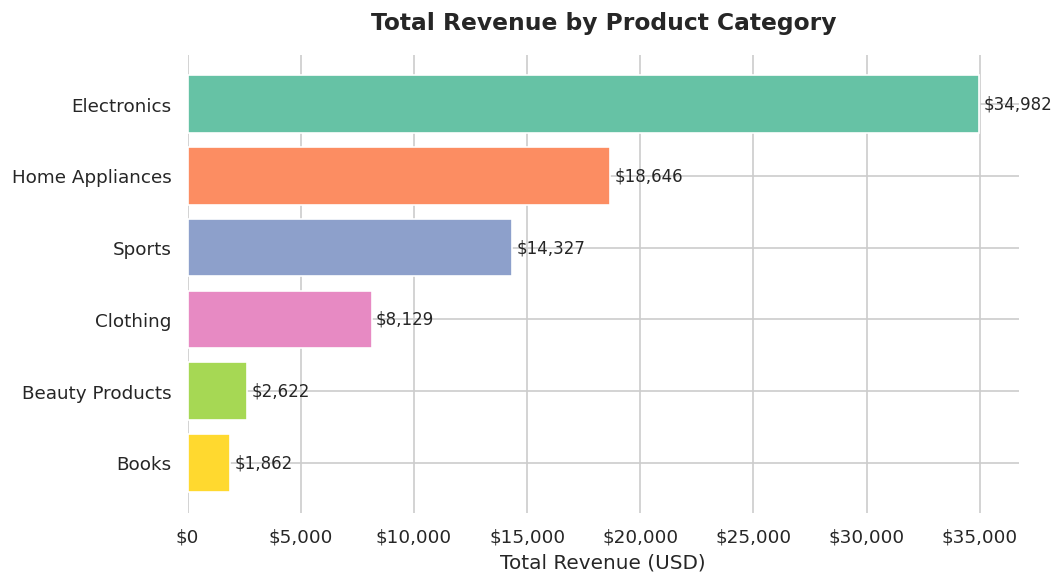


📊 Insight: Electronics leads in total revenue, driven by high unit prices.


In [13]:
category_revenue = (
    df.groupby('Product Category')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    category_revenue['Product Category'],
    category_revenue['Total Revenue'],
    color=sns.color_palette('Set2', len(category_revenue))
)

# Add value labels
for bar in bars:
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va='center', fontsize=10
    )

ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('chart1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: Electronics leads in total revenue, driven by high unit prices.')

### 5.2 Monthly Revenue Trend

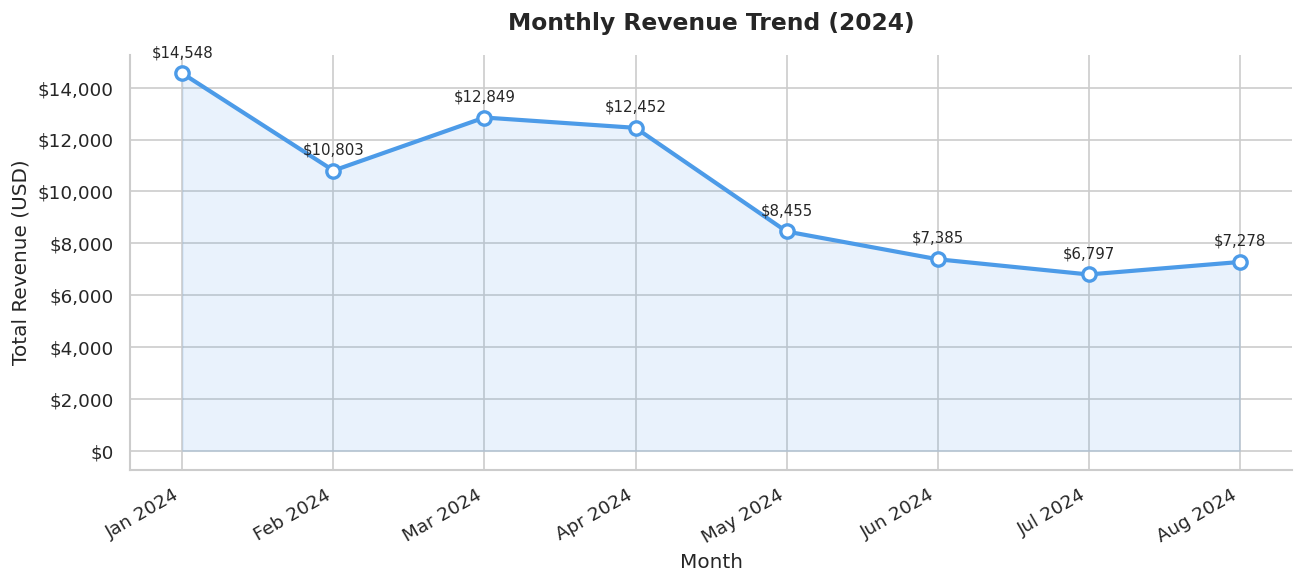


📊 Insight: Identify peak and low revenue months to inform promotions strategy.


In [15]:
monthly_revenue = (
    df.groupby(['Month_Num', 'Month_Name'])['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Month_Num')
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    monthly_revenue['Month_Name'],
    monthly_revenue['Total Revenue'],
    marker='o', linewidth=2.5,
    color='#4C9BE8', markerfacecolor='white',
    markeredgewidth=2, markersize=8
)
ax.fill_between(
    monthly_revenue['Month_Name'],
    monthly_revenue['Total Revenue'],
    alpha=0.12, color='#4C9BE8'
)

# Value labels on each point
for _, row in monthly_revenue.iterrows():
    ax.annotate(
        f"${row['Total Revenue']:,.0f}",
        (row['Month_Name'], row['Total Revenue']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=9
    )

ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (USD)')
ax.set_title('Monthly Revenue Trend (2024)', fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('chart2_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: Identify peak and low revenue months to inform promotions strategy.')

### 5.3 Revenue & Units Sold by Region

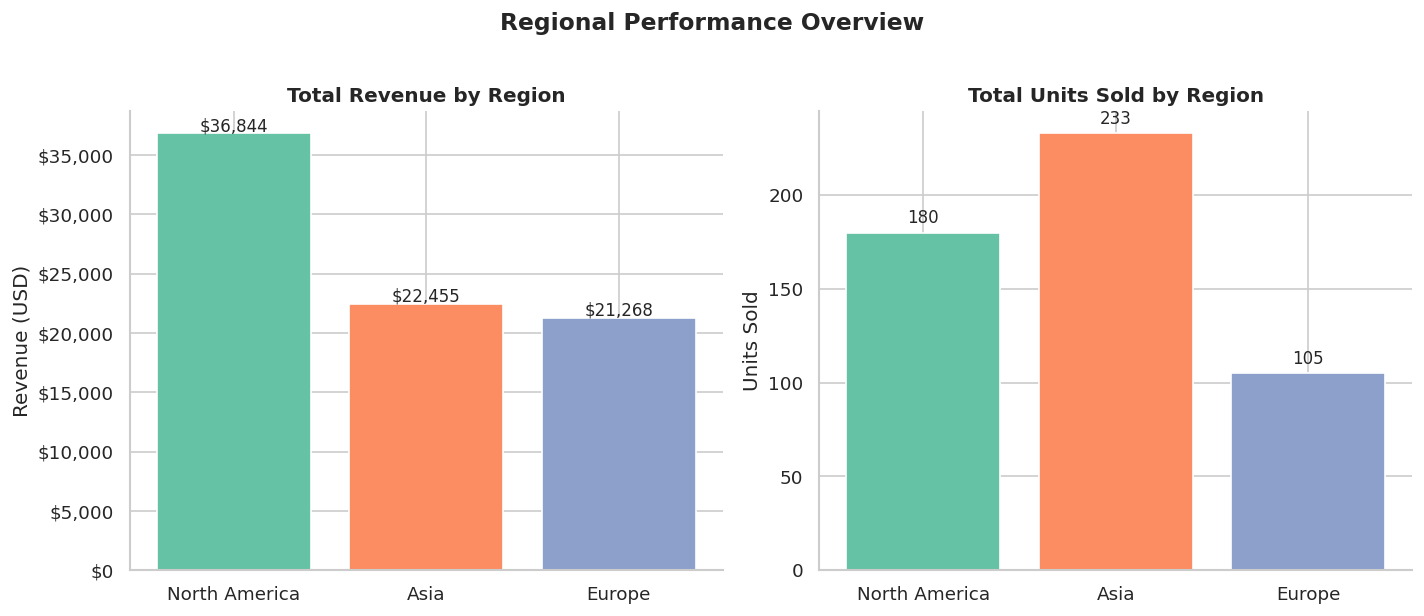


📊 Insight: Compare revenue vs units — a region with high units but low revenue signals lower-priced product mix.


In [16]:
region_stats = (
    df.groupby('Region')
    .agg(Total_Revenue=('Total Revenue', 'sum'),
         Total_Units=('Units Sold', 'sum'),
         Transactions=('Transaction ID', 'count'))
    .sort_values('Total_Revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = sns.color_palette('Set2', len(region_stats))

# Revenue by Region
bars1 = axes[0].bar(region_stats['Region'], region_stats['Total_Revenue'], color=colors)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"${bar.get_height():,.0f}", ha='center', fontsize=10)
axes[0].set_title('Total Revenue by Region', fontweight='bold')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[0])

# Units sold by Region
bars2 = axes[1].bar(region_stats['Region'], region_stats['Total_Units'], color=colors)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{int(bar.get_height())}", ha='center', fontsize=10)
axes[1].set_title('Total Units Sold by Region', fontweight='bold')
axes[1].set_ylabel('Units Sold')
sns.despine(ax=axes[1])

plt.suptitle('Regional Performance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: Compare revenue vs units — a region with high units but low revenue signals lower-priced product mix.')

### 5.4 Payment Method Distribution

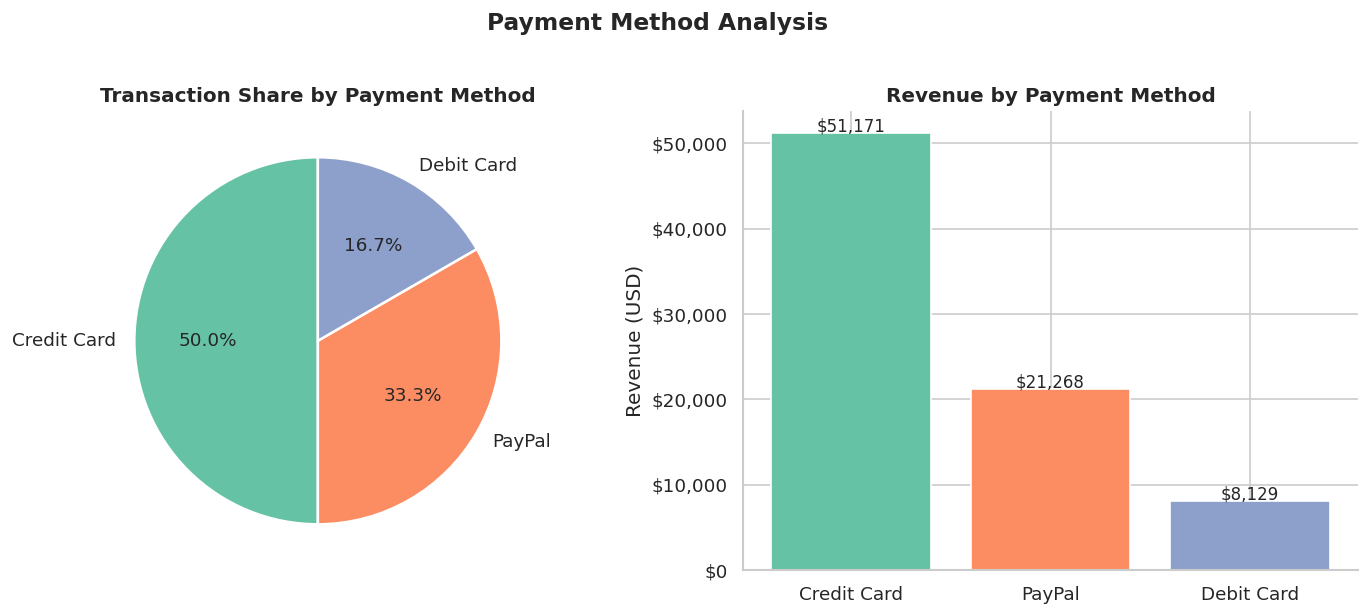


📊 Insight: Credit Cards dominate — consider incentivising PayPal/Debit to diversify payment risk.


In [17]:
payment_counts = df['Payment Method'].value_counts().reset_index()
payment_counts.columns = ['Payment Method', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart — share of transactions
axes[0].pie(
    payment_counts['Count'],
    labels=payment_counts['Payment Method'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(payment_counts)),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Transaction Share by Payment Method', fontweight='bold')

# Bar chart — revenue by payment method
payment_revenue = (
    df.groupby('Payment Method')['Total Revenue']
    .sum().sort_values(ascending=False).reset_index()
)
bars = axes[1].bar(
    payment_revenue['Payment Method'],
    payment_revenue['Total Revenue'],
    color=sns.color_palette('Set2', len(payment_revenue))
)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"${bar.get_height():,.0f}", ha='center', fontsize=10)
axes[1].set_title('Revenue by Payment Method', fontweight='bold')
axes[1].set_ylabel('Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[1])

plt.suptitle('Payment Method Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: Credit Cards dominate — consider incentivising PayPal/Debit to diversify payment risk.')

### 5.5 Units Sold vs Revenue — Scatter Plot

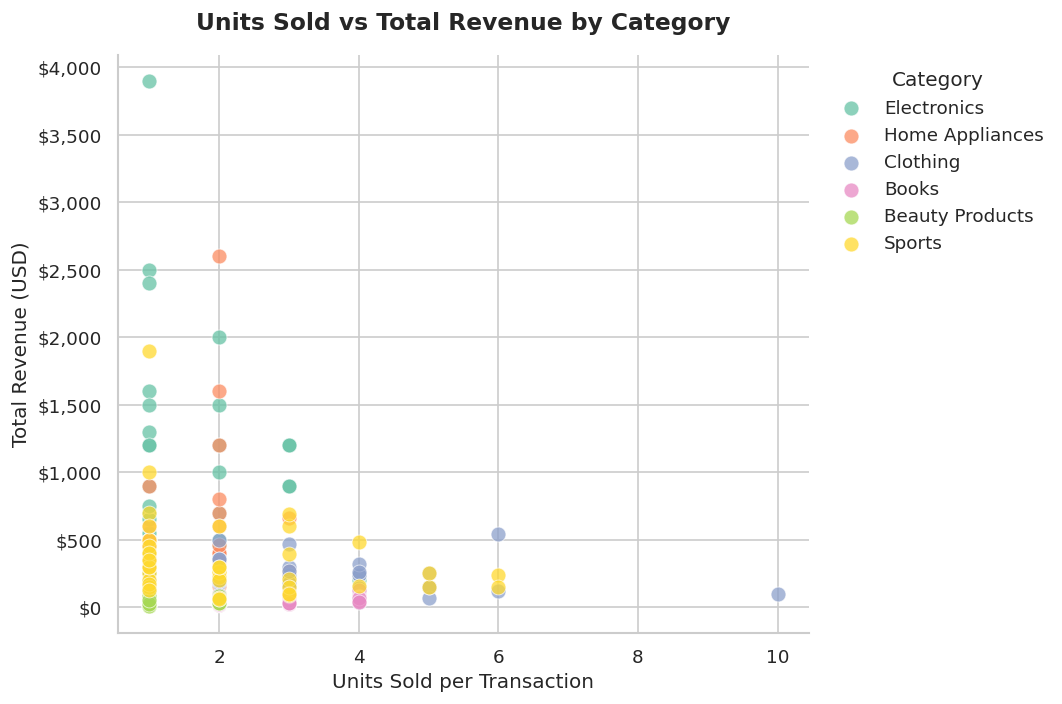


📊 Insight: Electronics shows high revenue with low unit counts — high-value, low-volume category.


In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

categories = df['Product Category'].unique()
palette = dict(zip(categories, sns.color_palette('Set2', len(categories))))

for cat in categories:
    subset = df[df['Product Category'] == cat]
    ax.scatter(
        subset['Units Sold'],
        subset['Total Revenue'],
        label=cat,
        color=palette[cat],
        alpha=0.75, s=80, edgecolors='white', linewidth=0.5
    )

ax.set_xlabel('Units Sold per Transaction')
ax.set_ylabel('Total Revenue (USD)')
ax.set_title('Units Sold vs Total Revenue by Category', fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('chart5_units_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: Electronics shows high revenue with low unit counts — high-value, low-volume category.')

### 5.6 Top 10 Products by Revenue

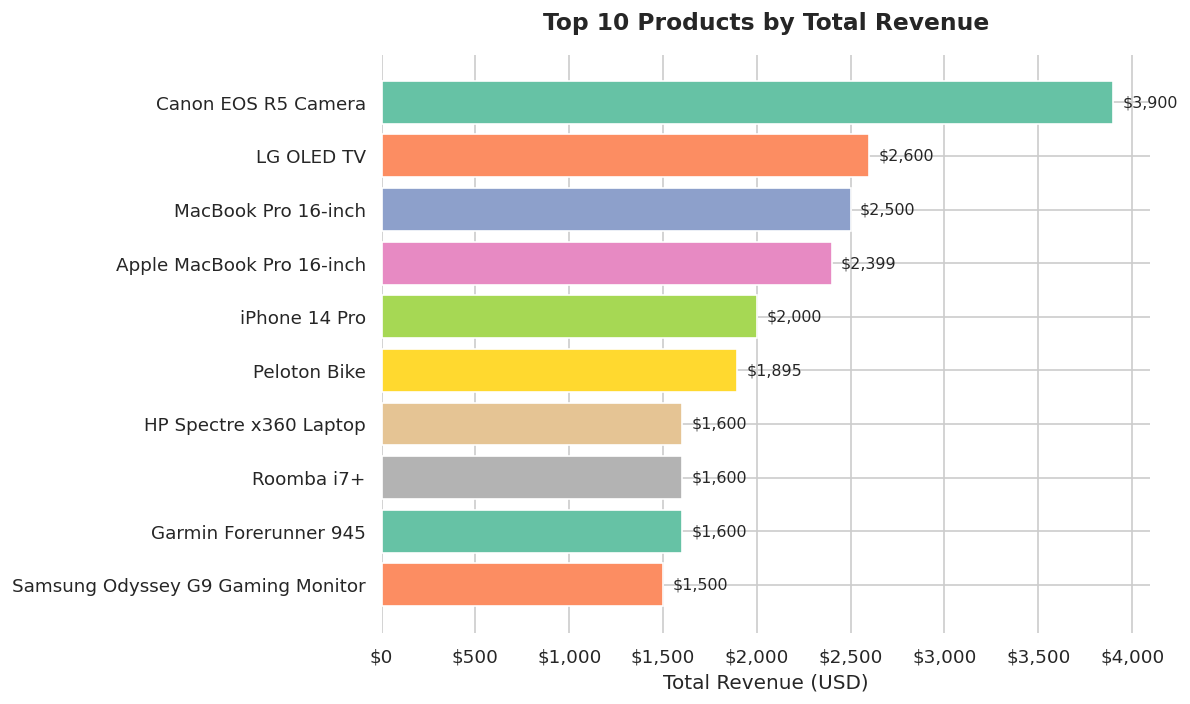


📊 Insight: MacBook Pro and high-end electronics dominate — premium products drive the most revenue.


In [19]:
top_products = (
    df.groupby('Product Name')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_products['Product Name'],
    top_products['Total Revenue'],
    color=sns.color_palette('Set2', 10)
)
for bar in bars:
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va='center', fontsize=9.5
    )

ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('chart6_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: MacBook Pro and high-end electronics dominate — premium products drive the most revenue.')

---
## 6. Key Insights & Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | **Electronics** is the top revenue category | Prioritise inventory and promotions for Electronics |
| 2 | **Credit Card** is the dominant payment method | Ensure credit card checkout is seamless; offer rewards |
| 3 | Revenue shows **monthly variation** | Plan targeted campaigns during low-revenue months |
| 4 | **North America** leads in revenue | Explore growth opportunities in under-performing regions |
| 5 | High-ticket products drive disproportionate revenue | Upsell accessories alongside premium items |
| 6 | Asia leads in **units sold** but not revenue | Suggests lower-priced product mix — potential to introduce premium options |

---

###Conclusion
This EDA reveals that the business is heavily driven by Electronics in North America, with Credit Card as the preferred payment method. Revenue shows monthly fluctuations, suggesting seasonal demand. To grow, the business should explore premium product offerings in Asia, diversify payment options, and align promotions with low-revenue months.
